In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:/Data_Science/EDA/IPL_Dataset.csv")

In [9]:
max_matches = df[['Player', 'Matches']].sort_values(by='Matches', ascending=False).iloc[0]
max_matches

Player     Shreyas Iyer
Matches              17
Name: 3, dtype: object

In [8]:
top_avg_players = df[df['50'] >= 2].nlargest(2, 'Avg')[['Player', 'Avg']]
top_avg_players

,Player,Avg
36,Wriddhiman Saha,71.33
4,Ishan Kishan,57.33


In [13]:
df[['First Name', 'Last Name']] = df['Player'].astype(str).str.split(n=1, expand=True)
df

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,First Name,Last Name
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0,Khaleel,Ahmed
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0,Arshdeep,Singh
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0,Daniel,Sams
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0,Shreevats,Goswami


In [14]:
df['Cleaned_Highest_Score'] = df['Highest Score'].astype(str).str.replace(r'\*', '', regex=True).astype(int)
df

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,First Name,Last Name,Cleaned_Highest_Score
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner,85
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0,Khaleel,Ahmed,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0,Arshdeep,Singh,0
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0,Daniel,Sams,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0,Shreevats,Goswami,0


In [15]:
total_centuries = df['100'].sum()
print("Total centuries:", total_centuries)

Total centuries: 5


In [19]:
avg_strike_rate = df['Strike rate'].mean()
low_sr_players = df[df['Strike rate'] < avg_strike_rate][['Player', 'Strike rate']]
print(f"Players with strike rate below average ({avg_strike_rate:.2f}):")
print(low_sr_players.to_string(index=False))
print(f"\nAverage Strike Rate of all players: {avg_strike_rate:.2f}")

Players with strike rate below average (107.36):
             Player  Strike rate
     Ajinkya Rahane       105.60
      Glenn Maxwell       101.88
      Vijay Shankar       101.04
      Josh Philippe       101.29
    Gurkeerat Singh        88.75
       Kedar Jadhav        93.93
   Yashasvi Jaiswal        90.90
      Shreyas Gopal        94.87
       Murali Vijay        74.41
       Chris Jordan        93.54
      Navdeep Saini       100.00
  Kamlesh Nagarkoti        70.96
      Harshal Patel        87.50
      Jimmy Neesham       105.55
         Tom Banton        90.00
  Prabhsimran Singh       100.00
      Kuldeep Yadav        61.90
          Moeen Ali        75.00
     Sandeep Sharma        80.00
     Shardul Thakur        57.14
        Rinku Singh       100.00
        Shivam Mavi        71.42
Varun Chakaravarthy        66.66
     Jaydev Unadkat        69.23
      Ankit Rajpoot        90.00
     Shahbaz Nadeem        87.50
       Pravin Dubey        53.84
      Deepak Chahar        

Red/Blue colors indicate strong positive/negative correlations between features.


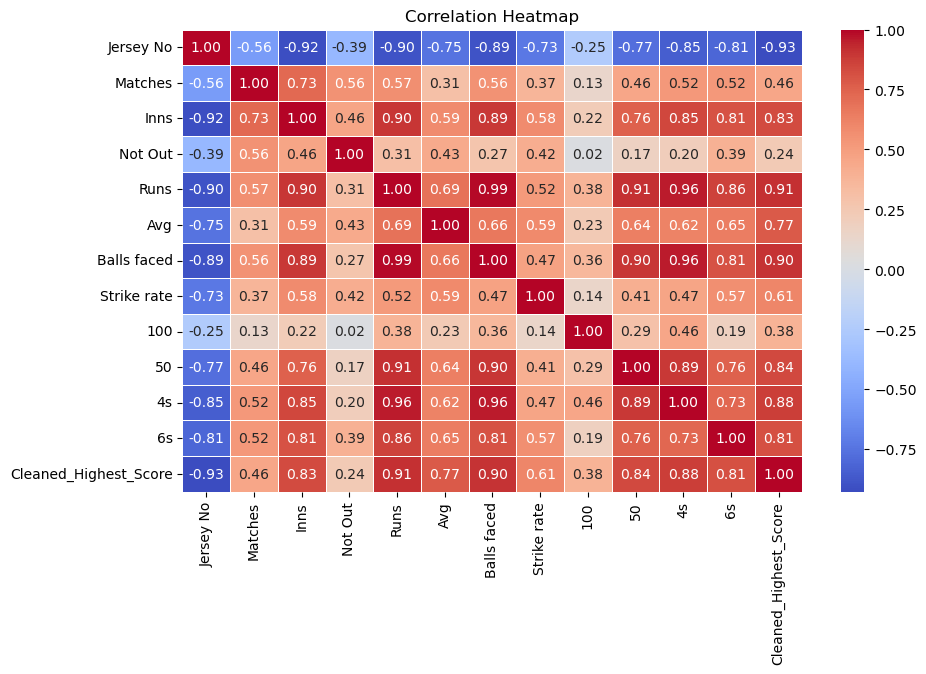

In [21]:
numeric_df = df.select_dtypes(include=['number'])

# Q7: Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
print("Red/Blue colors indicate strong positive/negative correlations between features.")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
filtered_players = df[(df['Avg'] > 50) & (df['Strike rate'] > 120)][['Player', 'Avg', 'Strike rate']]
print("Players with Average > 50 and Strike Rate > 120:\n", filtered_players.to_string(index=False))

Players with Average > 50 and Strike Rate > 120:
          Player    Avg  Strike rate
       KL Rahul  55.83       129.34
   Ishan Kishan  57.33       145.76
 Kieron Pollard  53.60       191.42
Wriddhiman Saha  71.33       139.86
Ruturaj Gaikwad  51.00       120.71
   Deepak Hooda 101.00       142.25
     Tom Curran  83.00       133.87


In [24]:
filtered_players = df[(df['Avg'] > 40) & (df['Balls faced'] > 100)][['Player', 'Avg', 'Balls faced']]
print("Players with Average > 40 and Balls Faced > 100:\n", filtered_players.to_string(index=False))

Players with Average > 40 and Balls Faced > 100:
          Player   Avg  Balls faced
       KL Rahul 55.83          518
 Shikhar Dhawan 44.14          427
   Ishan Kishan 57.33          354
    Virat Kohli 42.36          384
   ABD Villiers 45.40          286
  Faf Duplessis 40.81          319
    Eoin Morgan 41.80          302
Kane Williamson 45.28          237
    Chris Gayle 41.14          210
     Ben Stokes 40.71          200
 Kieron Pollard 53.60          140
  Rahul Tewatia 42.50          183
Ravindra Jadeja 46.40          135
Wriddhiman Saha 71.33          153
Ruturaj Gaikwad 51.00          169


Players who scored at least 1 century:
         Player  100
      KL Rahul    1
Shikhar Dhawan    2
Mayank Agarwal    1
    Ben Stokes    1


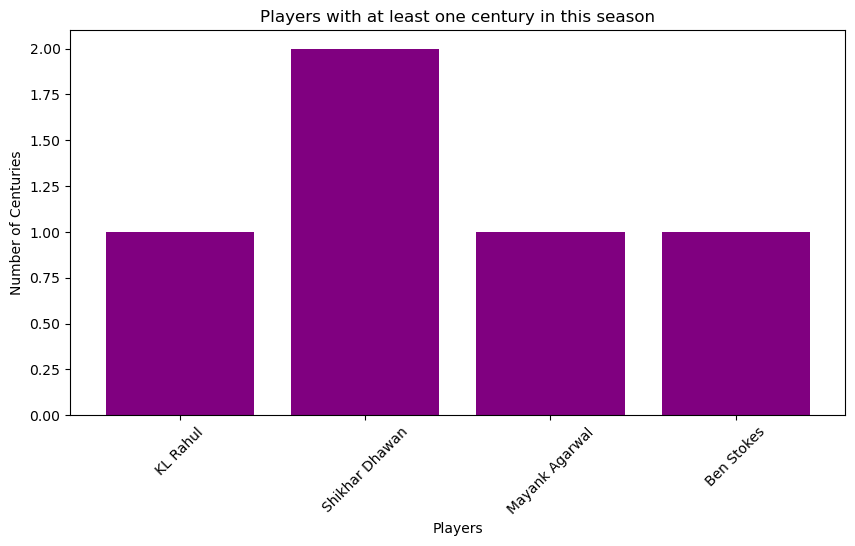

In [29]:
century_players = df[df['100'] > 0][['Player', '100']]
print("Players who scored at least 1 century:\n", century_players.to_string(index=False))
plt.figure(figsize=(10, 5))
plt.bar(century_players['Player'], century_players['100'], color='Purple')
plt.xlabel("Players")
plt.ylabel("Number of Centuries")
plt.title("Players with at least one century in this season")
plt.xticks(rotation=45)
plt.show()

In [31]:
half_century_players = df[df['50'] >= 4][['Player', '50']]
print(half_century_players)

              Player  50
0           KL Rahul   5
1     Shikhar Dhawan   4
2       David Warner   4
4       Ishan Kishan   4
5       Quinton Kock   4
6   Suryakumar Yadav   4
7   Devdutt Padikkal   5
9       ABD Villiers   5
10     Faf Duplessis   4


In [32]:
boundary_six_players = df[(df['4s'] > 45) & (df['6s'] > 10)][['Player', '4s', '6s']]
print(boundary_six_players)

             Player  4s  6s
0          KL Rahul  58  23
1    Shikhar Dhawan  67  12
2      David Warner  52  14
5      Quinton Kock  46  22
6  Suryakumar Yadav  61  11


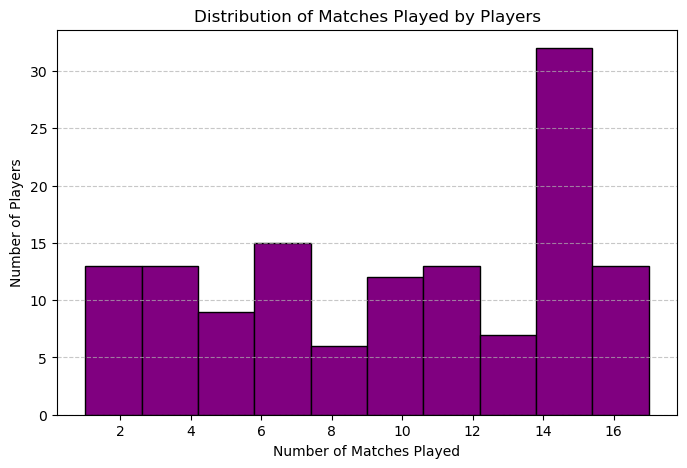

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(df['Matches'], bins=10, color='Purple', edgecolor='black')
plt.xlabel("Number of Matches Played")
plt.ylabel("Number of Players")
plt.title("Distribution of Matches Played by Players")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

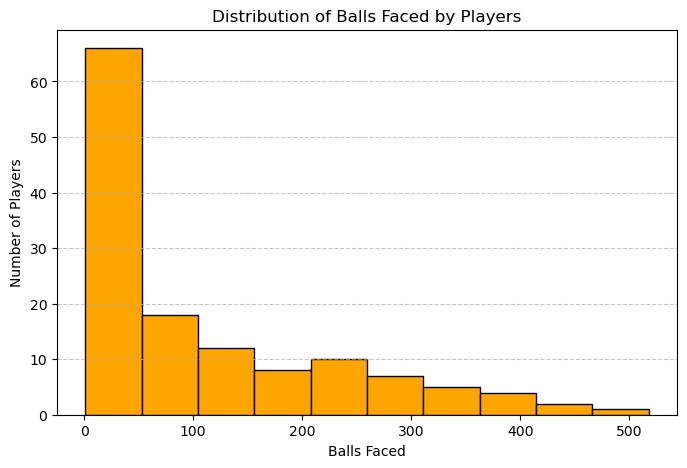

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(df['Balls faced'], bins=10, color='orange', edgecolor='black')
plt.xlabel("Balls Faced")
plt.ylabel("Number of Players")
plt.title("Distribution of Balls Faced by Players")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [42]:
top_10_scorers = df[['Player', 'Runs']].sort_values(by='Runs', ascending=False).head(10)
print("Top 10 players with most runs in a season:\n", top_10_scorers.to_string(index=False))

Top 10 players with most runs in a season:
           Player  Runs
        KL Rahul   670
  Shikhar Dhawan   618
    David Warner   548
    Shreyas Iyer   519
    Ishan Kishan   516
    Quinton Kock   503
Suryakumar Yadav   480
Devdutt Padikkal   473
     Virat Kohli   466
    ABD Villiers   454


In [45]:
if 'Inns' in df.columns and 'Matches' in df.columns:
    players_did_not_bat = df[df['Inns'] == 0][['Player', 'Matches']]
    
    if not players_did_not_bat.empty:
        print("Q16: Players who played but didn't bat:\n", players_did_not_bat.to_string(index=False))
    else:
        print("✅ All players who played have batted at least once.")
else:
    print("⚠️ Column 'Inns' or 'Matches' not found in dataset. Please verify column names.")

✅ All players who played have batted at least once.


In [51]:
df['Boundary_Percentage'] = ((df['4s'] * 4 + df['6s'] * 6) / df['Runs']) * 100
df['Boundary_Percentage'].fillna(0, inplace=True)
top_boundary_players = df.nlargest(5, 'Boundary_Percentage')[['Player', 'Boundary_Percentage']]
top_boundary_players['Boundary_Percentage'] = top_boundary_players['Boundary_Percentage'].apply(lambda x: f"{x:.2f}%")
print("Top 5 players with maximum percentage of runs from 4s and 6s:\n", top_boundary_players.to_string(index=False))

Top 5 players with maximum percentage of runs from 4s and 6s:
        Player Boundary_Percentage
   Andrew Tye             100.00%
Andre Russell              76.92%
 Chris Morris              76.47%
Hardik Pandya              73.31%
 Sunil Narine              72.73%


C:\Users\rasik\AppData\Local\Temp\ipykernel_13956\1731525889.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Boundary_Percentage'].fillna(0, inplace=True)


In [53]:
df['Not_Out_Percentage'] = (df['Not Out'] / df['Inns']) * 100
df['Not_Out_Percentage'].fillna(0, inplace=True)
top_not_out_players = df.nlargest(5, 'Not_Out_Percentage')[['Player', 'Not_Out_Percentage']]
top_not_out_players['Not_Out_Percentage'] = top_not_out_players['Not_Out_Percentage'].apply(lambda x: f"{x:.2f}%")
print("Q18: Top 5 players with highest Not Out percentage:\n", top_not_out_players.to_string(index=False))

Q18: Top 5 players with highest Not Out percentage:
          Player Not_Out_Percentage
Gurkeerat Singh            100.00%
Lockie Ferguson            100.00%
    Imran Tahir            100.00%
  Mohammad Nabi            100.00%
   Pravin Dubey            100.00%


C:\Users\rasik\AppData\Local\Temp\ipykernel_13956\3881560759.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Not_Out_Percentage'].fillna(0, inplace=True)


C:\Users\rasik\AppData\Local\Temp\ipykernel_13956\3840692439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='6s', y='Player', data=top_six_hitters, palette='coolwarm')


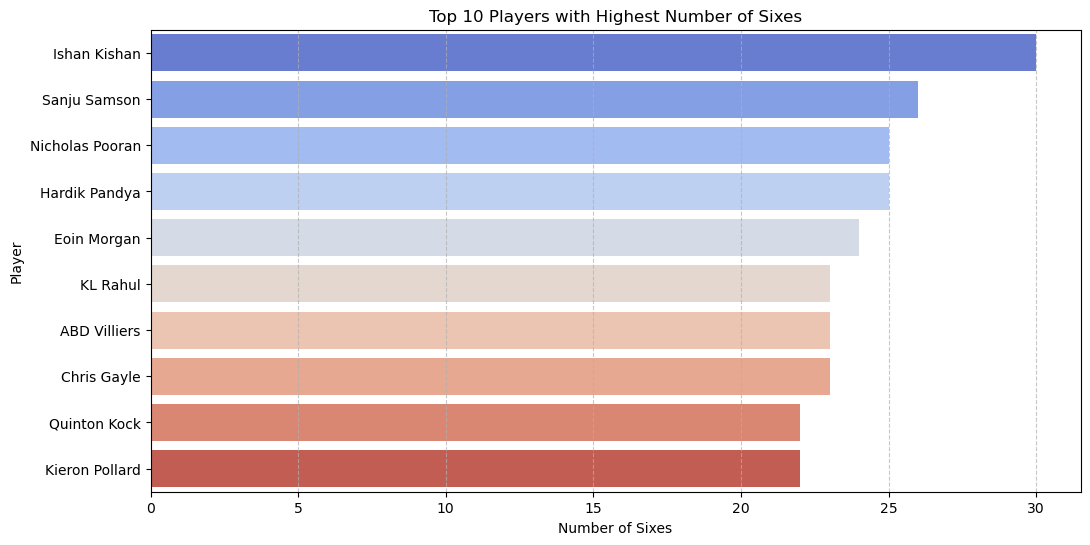

In [59]:
top_six_hitters = df.nlargest(10, '6s')[['Player', '6s']]
plt.figure(figsize=(12, 6))
sns.barplot(x='6s', y='Player', data=top_six_hitters, palette='coolwarm')
plt.xlabel("Number of Sixes")
plt.ylabel("Player")
plt.title("Top 10 Players with Highest Number of Sixes")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

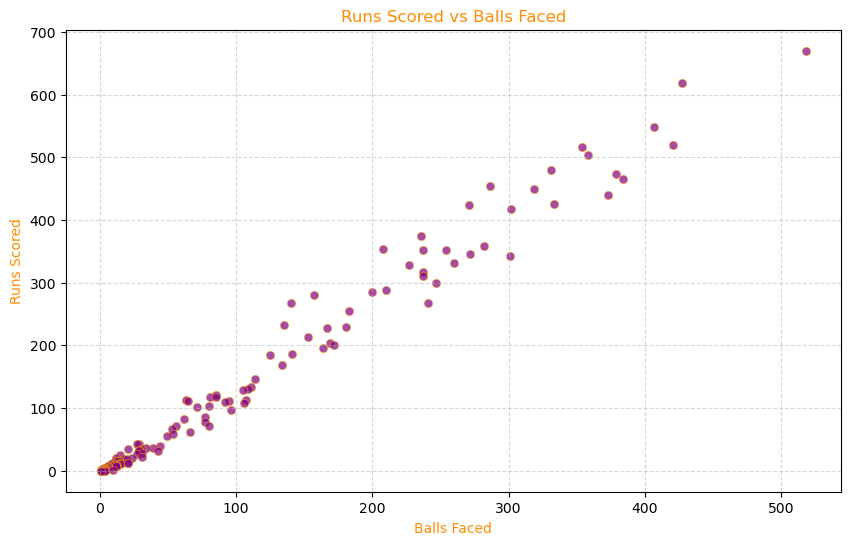

Correlation between Runs and Balls Faced: 0.99


In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Balls faced'], y=df['Runs'], color="purple", alpha=0.7, edgecolor="orange")
plt.xlabel("Balls Faced", color="darkorange")
plt.ylabel("Runs Scored", color="darkorange")
plt.title("Runs Scored vs Balls Faced", color="darkorange")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
correlation = df[['Balls faced', 'Runs']].corr().iloc[0, 1]
print(f"Correlation between Runs and Balls Faced: {correlation:.2f}")